In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

**LOADING THE DATA**

In [3]:
coInfo_stocks_marketindx = pd.read_csv("/content/drive/MyDrive/stock_market_analysis/merged_tables/coInfo_stocks_marketindx.csv", parse_dates=["date"])
# Sort by ticker AND date — very important!
# Each ticker is a separate stock. Indicators must be calculated per stock, not mixed across different companies.
coInfo_stocks_marketindx = coInfo_stocks_marketindx.sort_values(["ticker", "date"]).reset_index(drop=True)
print(f"Data loaded: {coInfo_stocks_marketindx.shape[0]} rows, {coInfo_stocks_marketindx['ticker'].nunique()} unique stocks")
print(f"   Date range: {coInfo_stocks_marketindx['date'].min().date()} → {coInfo_stocks_marketindx['date'].max().date()}")

Data loaded: 15600 rows, 20 unique stocks
   Date range: 2021-01-04 → 2023-12-29


In [4]:
coInfo_stocks_marketindx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticker          15600 non-null  object        
 1   company_name    15600 non-null  object        
 2   sector          15600 non-null  object        
 3   ipo_date        15600 non-null  object        
 4   date            15600 non-null  datetime64[ns]
 5   open            15600 non-null  float64       
 6   high            15600 non-null  float64       
 7   low             15600 non-null  float64       
 8   close           15600 non-null  float64       
 9   volume          15600 non-null  int64         
 10  adjusted_close  15600 non-null  float64       
 11  sp500_close     15600 non-null  float64       
 12  nasdaq_close    15600 non-null  float64       
 13  vix_close       15600 non-null  float64       
 14  treasury_10y    15600 non-null  float64       
 15  do

In [5]:
coInfo_stocks_marketindx['ipo_date'] = pd.to_datetime(coInfo_stocks_marketindx['ipo_date'])

In [6]:
coInfo_stocks_marketindx.columns.to_list()

['ticker',
 'company_name',
 'sector',
 'ipo_date',
 'date',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'adjusted_close',
 'sp500_close',
 'nasdaq_close',
 'vix_close',
 'treasury_10y',
 'dollar_index',
 'market_regime']

In [7]:
coInfo_stocks_marketindx.head()

,ticker,company_name,sector,ipo_date,date,open,high,low,close,volume,adjusted_close,sp500_close,nasdaq_close,vix_close,treasury_10y,dollar_index,market_regime
0,STK001,TechCorp,Technology,2021-01-04,2021-01-04,158.09,160.97,158.09,160.11,962644,160.11,3891.04,12952.02,20.48,1.496,90.07,bull
1,STK001,TechCorp,Technology,2021-01-04,2021-01-05,163.16,165.50,160.76,162.36,1312685,162.36,3847.20,13116.52,19.89,1.504,90.73,bull
2,STK001,TechCorp,Technology,2021-01-04,2021-01-06,161.89,162.51,160.94,161.78,1449177,161.78,3878.24,12818.48,20.02,1.507,90.46,bull
3,STK001,TechCorp,Technology,2021-01-04,2021-01-07,163.33,167.90,163.33,167.07,1534833,167.07,3803.95,13290.11,19.59,1.498,90.67,bull
4,STK001,TechCorp,Technology,2021-01-04,2021-01-08,168.20,168.20,164.12,165.68,848261,165.68,3715.64,13365.73,20.14,1.498,90.64,bull


**GROUPING BY TICKER TO GENERATE THE TECHNICAL INDICATOR**

In [8]:
g = coInfo_stocks_marketindx.groupby("ticker")

# =====================================================================================================
# INDICATOR 1 & 2: SIMPLE MOVING AVERAGE (SMA): This is the plain average of closing prices over N days
# =====================================================================================================

# FORMULA: SMA_N = average of last N closing prices
coInfo_stocks_marketindx["sma_20"]  = g["close"].transform(lambda x: x.rolling(window=20).mean())
coInfo_stocks_marketindx["sma_50"]  = g["close"].transform(lambda x: x.rolling(window=50).mean())
coInfo_stocks_marketindx["sma_200"] = g["close"].transform(lambda x: x.rolling(window=200).mean())

# NOTE: rolling(window=20).mean() needs at least 20 rows of data. The first 19 rows per ticker will be NaN — that's expected behaviour.

print("SMA 20, 50, 200 done")

# =====================================================
# INDICATOR 3, 4 & 5: EXPONENTIAL MOVING AVERAGE (EMA)
# =====================================================
# WHAT IT IS: Like SMA but gives MORE weight to recent prices.
# WHY IT'S USEFUL: Reacts faster to price changes than SMA.

coInfo_stocks_marketindx["ema_12"] = g["close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
coInfo_stocks_marketindx["ema_26"] = g["close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())

print("EMA 12, 26 done")

# ==================================================================
# INDICATOR 6, 7 & 8: MACD (Moving Average Convergence Divergence)
# ==================================================================
# WHAT IT IS: Shows the relationship between two EMAs.
# WHY IT'S USEFUL: Helps spot momentum shifts and buy/sell signals.
#
# Three parts:
#   MACD Line      = EMA_12 − EMA_26          (fast minus slow)
#   Signal Line    = EMA_9 of the MACD Line   (smoother version of MACD)
#   MACD Histogram = MACD Line − Signal Line  (distance between them)
#
# Positive histogram → bullish momentum building
# Negative histogram → bearish momentum building

coInfo_stocks_marketindx["macd"] = coInfo_stocks_marketindx["ema_12"] - coInfo_stocks_marketindx["ema_26"]

coInfo_stocks_marketindx["macd_signal"] = (
    coInfo_stocks_marketindx.groupby("ticker")["macd"]
    .transform(lambda x: x.ewm(span=9, adjust=False).mean())
)

coInfo_stocks_marketindx["macd_histogram"] = coInfo_stocks_marketindx["macd"] - coInfo_stocks_marketindx["macd_signal"]

print("MACD, Signal, Histogram done")

# =============================================================================
# INDICATOR 9: RSI (Relative Strength Index)
# =============================================================================
# WHAT IT IS: Measures how overbought or oversold a stock is (0–100 scale).
# WHY IT'S USEFUL:
#   RSI > 70 → possibly overbought (price may drop soon)
#   RSI < 30 → possibly oversold  (price may rise soon)
#
# FORMULA:
#   Step 1: Calculate daily price change
#   Step 2: Separate gains (positive changes) from losses (negative changes)
#   Step 3: Average gain and average loss over 14 days (using EMA)
#   Step 4: RS  = avg_gain / avg_loss
#   Step 5: RSI = 100 − (100 / (1 + RS))

def compute_rsi(series, period=14):
    delta = series.diff()                      # daily change
    gain  = delta.clip(lower=0)                # keep only positive changes
    loss  = (-delta).clip(lower=0)             # keep only negative changes (make positive)

    avg_gain = gain.ewm(span=period, adjust=False).mean()
    avg_loss = loss.ewm(span=period, adjust=False).mean()

    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

coInfo_stocks_marketindx["rsi_14"] = g["close"].transform(compute_rsi)

print("RSI 14 done")

# =============================================================================
# INDICATOR 10, 11, 12 & 13: BOLLINGER BANDS
# =============================================================================
# WHAT IT IS: A volatility band placed above and below a moving average.
# WHY IT'S USEFUL:
#   Price near upper band → potentially overbought
#   Price near lower band → potentially oversold
#   Wide bands → high volatility; Narrow bands → low volatility
#
# FORMULA:
#   Middle Band = SMA_20
#   Upper  Band = SMA_20 + (2 × standard deviation over 20 days)
#   Lower  Band = SMA_20 − (2 × standard deviation over 20 days)
#   BB Width    = (Upper − Lower) / Middle   ← normalised width

coInfo_stocks_marketindx["bb_middle"] = coInfo_stocks_marketindx["sma_20"]   # already calculated above

rolling_std = g["close"].transform(lambda x: x.rolling(window=20).std())

coInfo_stocks_marketindx["bb_upper"] = coInfo_stocks_marketindx["bb_middle"] + (2 * rolling_std)
coInfo_stocks_marketindx["bb_lower"] = coInfo_stocks_marketindx["bb_middle"] - (2 * rolling_std)
coInfo_stocks_marketindx["bb_width"]  = (coInfo_stocks_marketindx["bb_upper"] - coInfo_stocks_marketindx["bb_lower"]) / coInfo_stocks_marketindx["bb_middle"]

print("Bollinger Bands done")

# =============================================================================
# INDICATOR 14: TRUE RANGE (TR)
# =============================================================================
# WHAT IT IS: A more complete measure of a day's price range.
# WHY IT'S USEFUL: Accounts for overnight gaps that high-low alone misses.
#
# FORMULA: True Range = max of these three:
#   1. Today's High  − Today's Low
#   2. |Today's High − Yesterday's Close|
#   3. |Today's Low  − Yesterday's Close|

def compute_true_range(group):
    high       = group["high"]
    low        = group["low"]
    prev_close = group["close"].shift(1)   # yesterday's close

    tr = pd.concat([
        high - low,                        # range 1
        (high - prev_close).abs(),         # range 2
        (low  - prev_close).abs()          # range 3
    ], axis=1).max(axis=1)                 # take the largest of the three

    return tr

coInfo_stocks_marketindx["true_range"] = g.apply(compute_true_range).reset_index(level=0, drop=True)

print("True Range done")

# =============================================================================
# INDICATOR 15: ATR (Average True Range)
# =============================================================================
# WHAT IT IS: A 14-day smoothed average of the True Range.
# WHY IT'S USEFUL: Tells you how much a stock typically moves per day.
#   High ATR → volatile stock; Low ATR → calm stock.
#
# FORMULA: ATR_14 = EMA_14 of True Range

coInfo_stocks_marketindx["atr_14"] = (
    coInfo_stocks_marketindx.groupby("ticker")["true_range"]
    .transform(lambda x: x.ewm(span=14, adjust=False).mean())
)

print("ATR 14 done")

# =============================================================================
# INDICATOR 16 & 17: VOLUME INDICATORS
# =============================================================================
# WHAT THEY ARE:
#   volume_sma_20 → 20-day average of daily trading volume
#   volume_ratio  → today's volume ÷ 20-day average volume
#
# WHY IT'S USEFUL:
#   volume_ratio > 1 → more trading than usual (confirms price moves)
#   volume_ratio < 1 → quieter than usual (weak conviction)

coInfo_stocks_marketindx["volume_sma_20"] = g["volume"].transform(lambda x: x.rolling(window=20).mean())
coInfo_stocks_marketindx["volume_ratio"]  = coInfo_stocks_marketindx["volume"] / coInfo_stocks_marketindx["volume_sma_20"]

print("Volume SMA & Ratio done")

# =============================================================================
# INDICATOR 18 & 19: MOMENTUM
# =============================================================================
# WHAT IT IS: How much the price has changed over N days (rate of change).
# WHY IT'S USEFUL: Positive momentum = price is rising; negative = falling.
#
# FORMULA: Momentum_N = (Close_today / Close_N_days_ago) − 1
# Result is expressed as a decimal (e.g. 0.05 = +5% over N days)

coInfo_stocks_marketindx["momentum_10"] = g["close"].transform(lambda x: x.pct_change(periods=10))
coInfo_stocks_marketindx["momentum_20"] = g["close"].transform(lambda x: x.pct_change(periods=20))

print("Momentum 10 & 20 done")

# =============================================================================
# INDICATOR 20: PRICE TO SMA50 RATIO
# =============================================================================
# WHAT IT IS: How far the current price is from its 50-day average.
# WHY IT'S USEFUL:
#   > 1 → price is above the 50-day average (bullish)
#   < 1 → price is below the 50-day average (bearish)
#   = 1 → price is exactly at the average
#
# FORMULA: price_to_sma_50 = Close / SMA_50

coInfo_stocks_marketindx["price_to_sma_50"] = coInfo_stocks_marketindx["close"] / coInfo_stocks_marketindx["sma_50"]

print("Price-to-SMA50 done")


# =============================================================================
# INDICATOR 21: VOLATILITY (20-day Rolling)
# =============================================================================
# WHAT IT IS: Standard deviation of daily returns over the last 20 days,
#             then annualised by multiplying by √252 (trading days in a year).
# WHY IT'S USEFUL: Measures how "risky" or "jumpy" a stock has been recently.
#
# FORMULA:
#   Step 1: daily_return = (Close_today / Close_yesterday) − 1
#   Step 2: volatility_20 = std of last 20 daily returns × √252

coInfo_stocks_marketindx["daily_return"] = g["close"].transform(lambda x: x.pct_change())

coInfo_stocks_marketindx["volatility_20"] = (
    g["daily_return"]
    .transform(lambda x: x.rolling(window=20).std() * np.sqrt(252))
)

print("Volatility 20 done")


# =============================================================================
# INDICATOR 22: FUTURE RETURN (5-day Forward Return)
# =============================================================================
# WHAT IT IS: The actual return over the NEXT 5 trading days.
# WHY IT'S USEFUL: This is the TARGET variable in machine learning models —
#                  the "answer" we want to predict using all the other indicators.
#
# FORMULA: future_return_5d = (Close_5_days_later / Close_today) − 1
#
# IMPORTANT: shift(-5) looks FORWARD in time.
# The last 5 rows of each ticker will be NaN (no future data yet).

coInfo_stocks_marketindx["future_return_5d"] = g["close"].transform(
    lambda x: x.shift(-5) / x - 1
)

print("Future Return 5d done")

SMA 20, 50, 200 done
EMA 12, 26 done
MACD, Signal, Histogram done
RSI 14 done
Bollinger Bands done
True Range done
ATR 14 done
Volume SMA & Ratio done
Momentum 10 & 20 done
Price-to-SMA50 done
Volatility 20 done
Future Return 5d done


**CLEANING UP HELPER COLUMNS**

In [9]:
coInfo_stocks_marketindx.drop(columns=["daily_return"], inplace=True)

**SAVING THE RESULT**

In [ ]:
output_path = "/content/drive/MyDrive/stock_market_analysis/merged_tables/new_master_df.csv"
coInfo_stocks_marketindx.to_csv(output_path, index=False)

print(f"\n All done! File saved to: {output_path}")
print(f"   Final shape: {coInfo_stocks_marketindx.shape[0]} rows × {coInfo_stocks_marketindx.shape[1]} columns")

# Quick check — show NaN counts for each new indicator
indicator_cols = [
    "sma_20", "sma_50", "sma_200",
    "ema_12", "ema_26",
    "macd", "macd_signal", "macd_histogram",
    "rsi_14",
    "bb_middle", "bb_upper", "bb_lower", "bb_width",
    "true_range", "atr_14",
    "volume_sma_20", "volume_ratio",
    "momentum_10", "momentum_20",
    "price_to_sma_50",
    "volatility_20",
    "future_return_5d"
]

print("\n NaN counts per indicator (expected for warm-up periods):")
for col in indicator_cols:
    print(f"   {col:<22} → {coInfo_stocks_marketindx[col].isna().sum():>5} NaNs")

**DEFINING A LOGICAL FUNCTION TO GENERATE THE TARGET VARIABLE (trend_label)**

In [ ]:
new_master_df = pd.read_csv('/content/drive/MyDrive/stock_market_analysis/merged_tables/new_master_df.csv', parse_dates=['date'])

In [ ]:
# DEFINE THE THRESHOLDS: Storing thresholds as variables makes it easy to experiment later.

UPTREND_THRESHOLD   =  0.02   # +2%
DOWNTREND_THRESHOLD = -0.02   # -2%

# DEFINING A LOGICAL FUNCTION FOR THE TARGET VARIABLE
def target_variable(x):
  if x > UPTREND_THRESHOLD:
    return "Uptrend"
  elif x < DOWNTREND_THRESHOLD:
    return "Downtrend"
  elif np.isnan(x):
    return np.nan
  else:
    return "Sideways"

new_master_df['trend_label'] = new_master_df['future_return_5d'].apply(target_variable)

label_counts = new_master_df["trend_label"].value_counts()
label_pcts   = new_master_df["trend_label"].value_counts(normalize=True) * 100
print("\n trend_label column created!")
print("\n Overall Label Distribution:")
print("-" * 38)
for lbl in ["Uptrend", "Sideways", "Downtrend"]:
    count = label_counts.get(lbl, 0)
    pct   = label_pcts.get(lbl, 0)
    bar   = "█" * int(pct / 2)          # simple text bar chart
    print(f"   {lbl:<12} {count:>5} rows  ({pct:5.1f}%)  {bar}")
print("-" * 38)
print(f"   NaN          {new_master_df['trend_label'].isna().sum():>5} rows  (last 5 days per ticker)")

**VISUALISING THE DATAFRAME MISSING VALUES**

In [ ]:
# stock_indicator.isna().sum().plot(kind='bar', figsize=(15,6), color='teal')
ax = new_master_df.isna().sum().plot(kind='bar', figsize=(20,5), color='teal')

# Add missing-value labels on each bar
for p in ax.patches:
    value = int(p.get_height())
    ax.annotate(str(value),
    (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.tight_layout()
plt.show();


##### **Summary of Columns with Missing Values**

| Column Name        | Missing Count | Reason for Missingness (Summary)                     |
|--------------------|---------------|------------------------------------------------------|
| sma_200            | 3980          | Long lookback window → early rows lack enough data  |
| sma_50             | 980           | Rolling window → initial periods incomplete         |
| price_to_sma_50    | 980           | Depends on sma_50 → same missing pattern            |
| sma_20             | 380           | Shorter rolling window → fewer early gaps           |
| market_regime      | 380           | Derived indicator → missing where inputs missing    |
| bb_middle          | 380           | Bollinger Bands need rolling window                 |
| bb_upper           | 380           | Same as above                                       |
| bb_lower           | 380           | Same as above                                       |
| bb_width           | 380           | Same as above                                       |
| volume_sma_20      | 380           | Rolling volume window                               |
| momentum_10        | 200           | Needs 10‑day history                                |
| momentum_20        | 400           | Needs 20‑day history                                |
| volatility_20      | 400           | Rolling volatility window                           |
| future_return_5d   | 100           | Missing at dataset end (future data unavailable)    |
| trend_label        | 100           | Depends on future_return_5d → same pattern          |
| rsi_14             | 20            | Needs 14 periods → small initial gap                |


# **Performing EDA on the combined tables**

### **Engineering the `previous_close` and `daily_return` features to enhance analytical insight**

In [ ]:
new_master_df['previous_close'] = new_master_df.groupby('ticker')['close'].shift(1)

In [ ]:
new_master_df.head(2)

In [ ]:
new_master_df['daily_return'] = ((new_master_df['close'] - new_master_df['previous_close']) / new_master_df['previous_close']) * 100

In [ ]:
new_master_df.head(2)

In [ ]:
new_master_df.columns

**RE-ARRANGING THE ORDER OF VARIABLES IN THE DATAFRAME**

In [ ]:
new_order = ['ticker', 'company_name', 'sector',
             'ipo_date', 'date', 'open', 'high', 'low',
             'close', 'previous_close', 'daily_return' ,
             'volume', 'adjusted_close', 'sp500_close',
             'nasdaq_close', 'vix_close', 'treasury_10y',
             'dollar_index','market_regime', 'sma_20',
             'sma_50', 'sma_200', 'ema_12', 'ema_26',
             'macd', 'macd_signal', 'macd_histogram',
             'rsi_14', 'bb_middle','bb_upper', 'bb_lower',
             'bb_width', 'true_range', 'atr_14','volume_sma_20',
             'volume_ratio', 'momentum_10', 'momentum_20','price_to_sma_50',
             'volatility_20', 'future_return_5d', 'trend_label']

new_master_df = new_master_df[new_order]

In [ ]:
new_master_df.info()

###

### **Top 10 and Bottom 10 performing companies**

In [ ]:
# Calculate the average daily return for each company
avg_daily_return_by_company = (new_master_df.groupby('company_name')['daily_return'].mean().sort_values(ascending=False).reset_index())
plt.figure(figsize=(16, 6))

# Top 10 Companies
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=avg_daily_return_by_company.head(10), y='company_name', x='daily_return', palette='viridis')
plt.title('Top 10 Companies by Average Daily Return', weight='bold')
plt.xlabel('Average Daily Return', weight='bold')
plt.ylabel('Company Name', weight='bold')

# Adding values labels on each bar
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f')  # shows values with 4 decimal places

# Bottom 10 Companies
plt.subplot(1, 2, 2)  # second plot
ax2 = sns.barplot(data=avg_daily_return_by_company.tail(10), y='company_name',x='daily_return',palette='viridis')

plt.title('Bottom 10 Companies by Average Daily Return', weight='bold')
plt.xlabel('Average Daily Return', weight='bold')
plt.ylabel('Company Name', weight='bold')

# Add value labels on bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f')
plt.tight_layout()
plt.show();

**Interpretation of Top and Bottom 10 Companies by Average Daily Return**

| Category | Key Insights |
|----------|--------------|
| **Top 10 Companies by Average Daily Return** | - These firms show the strongest average daily returns, led by **TechCorp**.<br>- Most companies in this group demonstrate consistent positive performance.<br>- Tech, finance, and consumer‑focused sectors appear particularly strong. |
| **Bottom 10 Companies by Average Daily Return** | - These companies have the weakest average daily returns, with some falling into negative territory.<br>- A few still show small positive returns but lag far behind the top performers.<br>- **OilCorp** and others with negative returns indicate sustained underperformance. |

---


### **Sector Performance Comparison**

In [ ]:
avg_daily_return = (new_master_df.groupby('sector')['daily_return'].mean().reset_index())
avg_daily_return

In [ ]:
# 1. Calculate the average daily return for each sector
avg_daily_return = (new_master_df.groupby('sector')['daily_return'].mean().reset_index())
avg_volume_traded_by_sector = (new_master_df.groupby('sector')['volume'].mean().reset_index())

# 2. Create a bar plot
sns.set(style='darkgrid', palette='Set2', context='paper')
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=avg_daily_return, x='sector', y='daily_return', palette='Dark2')
plt.title('Average Daily Return by Sector', weight='bold')
plt.xlabel('Sector', weight='bold')
plt.ylabel('Average Daily Return', weight='bold')

# 3. Add value labels on top of each bar
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f')  # shows values with 4 decimal places
plt.subplot(1,2,2)
ax2 = sns.barplot(data=avg_volume_traded_by_sector, x='sector', y='volume', palette='Dark2')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f')  # shows values with 4 decimal places
plt.title('Average Volume Traded by Sector', weight='bold')
plt.xlabel('Sector', weight='bold')
plt.ylabel('Average Volume Traded', weight='bold')
plt.tight_layout()
plt.show();

**Interpretation of Sector Performance**

| Chart                               | Key Insights |
|-------------------------------------|--------------|
| **Average Daily Return by Sector**  | - **Finance** shows the highest average daily return.<br>- **Consumer, Technology, and Healthcare** deliver moderate positive returns.<br>- **Energy** has the lowest return among all sectors. |
| **Average Volume Traded by Sector** | - Trading volumes are **fairly consistent** across all sectors.<br>- **Energy and Healthcare** record slightly higher trading activity.<br>- **Consumer** has the lowest volume, though still close to others. |

---


### **Average Daily Return by Market Regime and Sector**

In [ ]:
new_master_df.groupby('market_regime')['daily_return'].mean().reset_index()

In [ ]:
plt.figure(figsize=(20, 6))
sns.barplot(data=new_master_df, x='market_regime', y='daily_return', hue='sector')
plt.title('Average Daily Return by Market Regime and Sector', weight='bold')
plt.xlabel('Market Regime', weight='bold')
plt.ylabel('Average Daily Return', weight='bold')
plt.show();

- Recovery periods show the strongest performance, with most sectors bouncing back into positive territory.

- Bear markets hit Technology and Energy the hardest, while Healthcare and Consumer sectors remain relatively more stable across regimes.

####

## **Sector Performance in Bull vs Bear Markets**

In [ ]:
new_master_df.columns

In [ ]:
pivot_regime = new_master_df.pivot_table(values='daily_return',index='sector',columns='market_regime',aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot_regime,annot=True,fmt=".4f",cmap="viridis")
plt.title("Sector Performance in Bull vs Bear Markets", weight='bold')
plt.xlabel("Market Regime",weight='bold')
plt.ylabel("Sector",weight='bold')
plt.tight_layout()
plt.show();

**Sector Performance Across Market Regimes**

| Market Regime | Key Insights |
|---------------|--------------|
| **Bear Market** | - **Energy** and **Technology** show strong negative performance.<br>- **Consumer** and **Healthcare** remain slightly positive, acting as defensive sectors.<br>- **Finance** dips mildly but performs better than Energy and Tech. |
| **Bull Market** | - All sectors turn positive, with **Energy** leading strongly.<br>- **Consumer** and **Finance** also perform well in bullish conditions.<br>- **Healthcare** shows the weakest positive performance. |
| **Recovery Market** | - **Technology** and **Finance** show the strongest rebound.<br>- **Healthcare** and **Energy** also recover well.<br>- **Consumer** recovers, but more modestly than other sectors. |
| **Sideways Market** | - Most sectors hover around zero with minimal movement.<br>- **Technology** and **Energy** show small positive returns.<br>- **Consumer** and **Healthcare** dip slightly negative. |

---


## **Stock Price Trend Over Time**

### **visualization the stock price over time for per 5 companies**

In [ ]:
# Get the first 5 unique companies
first_5_company_name = new_master_df['company_name'].unique()[:5]
second_5_company_name = new_master_df['company_name'].unique()[5:10]
third_5_company_name = new_master_df['company_name'].unique()[10:15]
last_5_company_name = new_master_df['company_name'].unique()[15:]

print(first_5_company_name)
print(second_5_company_name)
print(third_5_company_name)
print(last_5_company_name)

In [ ]:
# Keep only rows belonging to the first 5 comapanies
first5_companies = new_master_df[
    new_master_df['company_name'].isin(first_5_company_name)
]
plt.figure(figsize=(17,5))

plt.subplot(1,2,1)
sns.lineplot(data=first5_companies,x='date',y='close',hue='company_name')
plt.title('Stock Price Trend Over Time (First 5 companies)', weight='bold')
plt.xlabel('Date', weight='bold')
plt.ylabel('Closing Price', weight='bold')
plt.legend(title='Companies')

# Filter the dataset for only the second 5 companies
second5_companies = new_master_df[new_master_df['company_name'].isin(second_5_company_name)]
plt.subplot(1,2,2)
sns.lineplot(data=second5_companies,x='date',y='close',hue='company_name')
plt.title('Stock Price Trend Over Time (Second 5 companies)', weight='bold')
plt.xlabel('Date', weight='bold')
plt.ylabel('Closing Price', weight='bold')
plt.legend(title='Companies')
plt.tight_layout()
plt.show();

**Interpretation of Stock Price Trends (10 Companies)**

| Group | Key Insights |
|-------|--------------|
| **First 5 Companies**<br>(TechCorp, DataSystems, CloudNine, CyberShield, MediPharm) | - All companies show noticeable fluctuations over the 3‑year period, reflecting varying levels of volatility.<br>- **TechCorp** and **CloudNine** display stronger upward momentum compared to others.<br>- **DataSystems** and **CyberShield** show more irregular patterns, suggesting less stable performance. |
| **Second 5 Companies**<br>(BioGenix, HealthPlus, CareWell, CapitalBank, InvestPro) | - **CapitalBank** shows a steady upward trend, indicating consistent growth.<br>- **BioGenix** and **CareWell** exhibit moderate but stable increases over time.<br>- **HealthPlus** and **InvestPro** show flatter or more fluctuating trends, suggesting weaker momentum. |

---


In [ ]:
# Keep only rows belonging to the third 5 comapanies
third5_companies = new_master_df[
    new_master_df['company_name'].isin(third_5_company_name)
]
plt.figure(figsize=(17,5))

plt.subplot(1,2,1)
sns.lineplot(data=third5_companies,x='date',y='close',hue='company_name')
plt.title('Stock Price Trend Over Time (Third 5 companies)', weight='bold')
plt.xlabel('Date', weight='bold')
plt.ylabel('Closing Price', weight='bold')
plt.legend(title='Companies')

# Filter the dataset for only the last 5 companies
last5_companies = new_master_df[
    new_master_df['company_name'].isin(last_5_company_name)
]
plt.subplot(1,2,2)
sns.lineplot(data=last5_companies,x='date',y='close',hue='company_name')
plt.title('Stock Price Trend Over Time (Second 5 companies)', weight='bold')
plt.xlabel('Date', weight='bold')
plt.ylabel('Closing Price', weight='bold')
plt.legend(title='Companies')
plt.tight_layout()
plt.show();

**Interpretation of Stock Price Trends (Next 10 Companies)**

| Group | Key Insights |
|-------|--------------|
| **Third 5 Companies**<br>(FinSecure, WealthGroup, RetailMax, FoodChain, HomeStyle) | - **WealthGroup** and **FoodChain** show stronger upward momentum over time.<br>- **FinSecure** and **RetailMax** display moderate but steady growth patterns.<br>- **HomeStyle** shows more fluctuation, indicating less stable performance. |
| **Fourth 5 Companies**<br>(ShopEasy, PowerGen, GreenEnergy, OilCorp, RenewTech) | - **PowerGen** and **RenewTech** show the most consistent upward trends.<br>- **GreenEnergy** and **ShopEasy** fluctuate more, suggesting higher volatility.<br>- **OilCorp** shows weaker performance with a generally flatter or declining trend. |

---


## **Trading Volume Patterns**

In [ ]:
avg_volume_by_sector = (new_master_df.groupby('sector')['volume'].mean().sort_values(ascending=False).reset_index())
avg_volume_by_sector
# pie plot
plt.figure(figsize=(10,6))
ax = plt.subplot()
ax.pie(avg_volume_by_sector['volume'],labels=avg_volume_by_sector['sector'],autopct='%1.1f%%')
plt.title('Average Trading Volume by Sector', weight='bold')
plt.show();

| Sector | Key Insights |
|--------|--------------|
| **Energy** | - Holds the largest share of trading volume.<br>- Indicates strong market activity and investor interest. |
| **Technology** | - Very close to Energy in trading volume share.<br>- Reflects high engagement and liquidity in tech stocks. |
| **Finance** | - Nearly equal to Technology and Energy.<br>- Suggests steady and consistent trading activity. |
| **Consumer** | - Slightly lower share but still comparable to other sectors.<br>- Indicates balanced but moderate trading interest. |
| **Healthcare** | - Matches Consumer in trading volume share.<br>- Shows stable participation without major spikes. |

---


In [ ]:
# Calculate average trading volume for each company
avg_volume_by_company = (new_master_df.groupby('company_name')['volume'].mean().sort_values(ascending=False).reset_index())

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
ax1 = sns.barplot(data=avg_volume_by_company.head(10),x='company_name',y='volume',palette='viridis')
plt.title('Top 10 Companies by Average Trading Volume', weight='bold')
plt.xlabel('Companies', weight='bold')
plt.ylabel('Average Trading Volume', weight='bold')
for container in ax1.containers:       # Add values on top of bars
    ax1.bar_label(container, fmt='%.0f')

plt.subplot(1,2,2)
ax2 = sns.barplot(data=avg_volume_by_company.tail(5),x='company_name',y='volume',palette='cividis')
plt.title('Bottom 5 Companies by Average Trading Volume', weight='bold')
plt.xlabel('Companies', weight='bold')
plt.ylabel('Average Trading Volume', weight='bold')
for container in ax2.containers:       # Add values on top of bars
    ax2.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show();

**Interpretation of Average Trading Volume (Top & Bottom Companies)**

| Group | Key Insights |
|--------|--------------|
| **Top 10 Companies by Average Trading Volume** | - These companies show the **highest trading activity**, indicating strong market interest and liquidity.<br>- **GreenEnergy, OilCorp, and PowerGen** lead the group with the largest volumes.<br>- Tech‑related and financial firms (e.g., DataSystems, TechCorp, FinSecure) also appear prominently, reflecting active investor engagement. |
| **Bottom 5 Companies by Average Trading Volume** | - These firms still have **high trading volumes**, but slightly lower than the top group.<br>- **HomeStyle** and **MediPharm** sit at the upper end of this lower tier.<br>- **ShopEasy** has the lowest average volume among all companies shown, suggesting comparatively lower market activity. |

---


## **Market Regime Impact (Bull vs Bear)**

In [ ]:
# Calculating the average closing price during each market regime
avg_price_by_regime = (
    new_master_df
    .groupby('market_regime')['close']  # group by Bull vs Bear
    .mean()                             # calculate average closing price
    .reset_index()                      # convert to dataframe
)
# View the results
print(avg_price_by_regime)
plt.figure(figsize=(8,4))
ax = sns.barplot(
    data=avg_price_by_regime,
    x='market_regime',
    y='close',
    palette='bone'
)
plt.title('Average Stock Price in Bull vs Bear Markets', weight='bold')
plt.xlabel('Market Regime', weight='bold')
plt.ylabel('Average Closing Price', weight='bold')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.tight_layout()
plt.show();

- Stock prices behave differently across market regimes, with bull and sideways markets showing the strongest average prices.

- Bear and recovery markets show noticeably lower averages, reflecting weaker confidence and gradual stabilisation.

- Overall, the chart highlights how market conditions strongly influence typical stock price levels.

### **Relationship Between Market Indices and Stock Prices**

In [ ]:
plt.figure(figsize=(17,5))

plt.subplot(1,2,1)
sns.scatterplot(data=new_master_df,x='sp500_close',y='close',color='green')
plt.title('Relationship Between Stock Price and S&P 500 Index', weight='bold')
plt.xlabel('S&P 500 Closing Price', weight='bold')
plt.ylabel('Stock Closing Price', weight='bold')

plt.subplot(1,2,2)
sns.scatterplot(data=new_master_df,x='nasdaq_close',y='close',alpha=0.6,color='purple')
plt.title('Relationship Between Stock Price and NASDAQ Index', weight='bold')
plt.xlabel('NASDAQ Closing Price', weight='bold')
plt.ylabel('Stock Closing Price', weight='bold')

plt.tight_layout()
plt.show();

**Relationship Between Stock Price and S&P 500 Index**
- Stock prices generally rise as the S&P 500 increases, indicating a **positive correlation**.
- Higher S&P 500 levels tend to align with higher stock prices, reflecting broad market influence.

**Relationship Between Stock Price and NASDAQ Index**
- A similar positive relationship appears between stock prices and the NASDAQ index.
- The wider horizontal spread indicates the NASDAQ covers a broader range of values, but stock prices still trend upward with it.
- The pattern suggests tech‑heavy market movements (NASDAQ) have a **strong influence** on the stocks shown.



### **Average volatility by sector**

In [ ]:
# Create a new column called 'volatility'
new_master_df['volatility'] = (new_master_df['high'] - new_master_df['low'])

# View the first few rows
new_master_df[['ticker','company_name','sector','high','low','volatility']].head()

In [ ]:
volatility_by_sector = new_master_df.groupby('sector')['volatility'].mean().reset_index()
plt.figure(figsize=(10,5))
ax = sns.barplot(data=volatility_by_sector,x='sector',y='volatility',palette='cividis')
plt.title('Average Volatility by Sector', weight='bold')
plt.xlabel('Sector', weight='bold')
plt.ylabel('Average Volatility', weight='bold')
for container in ax.containers:       # Add values on top of bars
    ax.bar_label(container, fmt='%.2f')
plt.tight_layout()
plt.show();

- **Technology** is the most volatile sector, showing the highest price fluctuations.
- **Finance** also exhibits elevated volatility, reflecting sensitivity to economic conditions.
- **Energy** and **Healthcare** show moderate volatility levels.
- **Consumer** is the least volatile sector, indicating more stable and predictable price movements.

**Recommendation Based on Sector Volatility**

*The recommendation is to choose low‑volatility sectors for stability, moderate‑volatility sectors for balanced risk, and high‑volatility sectors only if seeking higher growth and comfortable with greater price swings.*

---

### **Average volatility by company**

In [ ]:
volatility_by_company = new_master_df.groupby('company_name')['volatility'].mean().reset_index()
plt.figure(figsize=(20,5))
ax = sns.barplot(data=volatility_by_company,x='company_name',y='volatility',palette='cividis')
plt.title('Average Volatility by Company', weight='bold')
plt.xlabel('Company', weight='bold')
plt.ylabel('Average Volatility', weight='bold')
for container in ax.containers:       # Add values on top of bars
    ax.bar_label(container, fmt='%.2f')
plt.tight_layout()
plt.show();

- **TechCorp** and **CloudNine** show the highest volatility, indicating large price swings and higher risk.
- **CyberShield**, **DataSystems**, **FinSecure**, and **WealthGroup** exhibit moderately high volatility, suggesting active but less extreme movement.
- **BioGenix**, **FoodChain**, **GreenEnergy**, **MediPharm**, **OilCorp**, **PowerGen**, **RenewTech**, and **RetailMax** fall in the mid‑volatility range.
- **HealthPlus**, **HomeStyle**, and **ShopEasy** have the lowest volatility, reflecting more stable and predictable price behaviour.

---

### **Investigating the impact of Interest Rate on Stocks**

In [ ]:
# Preview the cleaned dataset
new_master_df[['treasury_10y', 'close']].head()

plt.figure(figsize=(10,6))
sns.scatterplot(data=new_master_df,x='treasury_10y',y='close',color='green')
plt.title('Impact of 10-Year Treasury Yield on Stock Prices', weight='bold')
plt.xlabel('10-Year Treasury Yield', weight='bold')
plt.ylabel('Stock Closing Price', weight='bold')

plt.tight_layout()
plt.show();

- Stock prices tend to **increase as the 10-year Treasury yield rises**, indicating a generally positive relationship.
- At **lower yield levels**, stock prices cluster tightly between 100 and 200, suggesting more stable pricing.
- As yields move **above roughly 2.2**, stock prices show **greater variability**, including higher price levels.
- The spread of points implies that while yields influence stock prices, **individual stocks respond differently**, reflecting varying sensitivity to interest rate changes.

---

### **Correlation between the Dollar Strength and the Stock values**

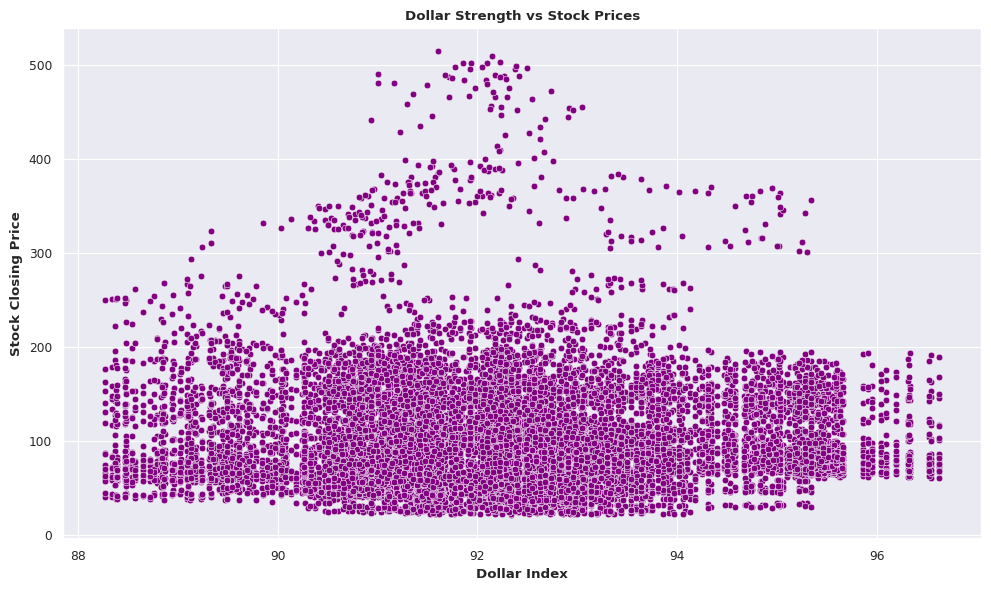

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=new_master_df,
    x='dollar_index',
    y='close',
    color='purple'
)

plt.title('Dollar Strength vs Stock Prices', weight='bold')
plt.xlabel('Dollar Index', weight='bold')
plt.ylabel('Stock Closing Price', weight='bold')

plt.tight_layout()
plt.show()

- Stock prices remain mostly clustered between 50 and 200 across the full range of dollar index values.
- A noticeable upward spread appears around the 91–93 range, suggesting some stocks rise as the dollar strengthens.
- The overall pattern hints at a **mild positive relationship**, though not a strong or uniform one.
- The wide vertical spread indicates that individual stocks respond differently to changes in dollar strength.

---


In [ ]:
new_master_df.to_csv('/content/drive/MyDrive/stock_market_analysis/merged_tables/new_master_df2.csv')

In [ ]:
new_master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticker            15600 non-null  object        
 1   company_name      15600 non-null  object        
 2   sector            15600 non-null  object        
 3   ipo_date          15600 non-null  object        
 4   date              15600 non-null  datetime64[ns]
 5   open              15600 non-null  float64       
 6   high              15600 non-null  float64       
 7   low               15600 non-null  float64       
 8   close             15600 non-null  float64       
 9   previous_close    15580 non-null  float64       
 10  daily_return      15580 non-null  float64       
 11  volume            15600 non-null  int64         
 12  adjusted_close    15600 non-null  float64       
 13  sp500_close       15600 non-null  float64       
 14  nasdaq_close      1560

In [ ]:
new_master_df.columns.tolist()

['ticker',
 'company_name',
 'sector',
 'ipo_date',
 'date',
 'open',
 'high',
 'low',
 'close',
 'previous_close',
 'daily_return',
 'volume',
 'adjusted_close',
 'sp500_close',
 'nasdaq_close',
 'vix_close',
 'treasury_10y',
 'dollar_index',
 'market_regime',
 'sma_20',
 'sma_50',
 'sma_200',
 'ema_12',
 'ema_26',
 'macd',
 'macd_signal',
 'macd_histogram',
 'rsi_14',
 'bb_middle',
 'bb_upper',
 'bb_lower',
 'bb_width',
 'true_range',
 'atr_14',
 'volume_sma_20',
 'volume_ratio',
 'momentum_10',
 'momentum_20',
 'price_to_sma_50',
 'volatility_20',
 'future_return_5d',
 'trend_label',
 'volatility']

# **MODELS TRAINING**

In [ ]:
# Import the libraries we need
import pandas as pd          # for working with tables of data
import numpy as np           # for math operations
from sklearn.linear_model    import LogisticRegression        # Model 1
from sklearn.ensemble        import RandomForestClassifier    # Model 3
from sklearn.neighbors       import KNeighborsClassifier      # Model 4
from sklearn.model_selection import train_test_split  # to split data
from sklearn.metrics         import classification_report, accuracy_score
from sklearn.metrics import classification_report     # to measure accuracy
from sklearn.preprocessing import LabelEncoder        # turns text labels → numbers
from sklearn.preprocessing   import StandardScaler
import joblib                # to save/load our trained model
import warnings
warnings.filterwarnings("ignore")   # hide noisy warnings for now

In [ ]:
# XGBoost is a separate library (very popular in competitions)
try:
    from xgboost import XGBClassifier   # Model 2
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed. Run: pip install xgboost")
    print("   Continuing with 3 models...\n")

In [ ]:
print(" Loading data...")
new_master_df2 = pd.read_csv("/content/drive/MyDrive/stock_market_analysis/merged_tables/new_master_df2.csv", index_col=0)
print(f"   Loaded {len(new_master_df2):,} rows and {len(new_master_df2.columns)} columns")

 Loading data...
   Loaded 15,600 rows and 43 columns


**Choosing which columns to use for models training**

In [ ]:
# Choose which columns to use as "features"
# Features = the information our model learns from
# We pick technical indicators that traders already know are useful

FEATURE_COLUMNS = [
    "rsi_14",           # Relative Strength Index (momentum indicator)
    "macd",             # Moving Average Convergence Divergence
    "macd_histogram",   # Difference between MACD and its signal line
    "bb_width",         # Bollinger Band width (measures volatility)
    "volume_ratio",     # Today's volume vs average volume
    "momentum_10",      # Price momentum over 10 days
    "momentum_20",      # Price momentum over 20 days
    "price_to_sma_50",  # How far price is from its 50-day average
    "volatility_20",    # 20-day rolling volatility
    "atr_14",           # Average True Range (measures price movement)
    "daily_return",     # Today's percentage price change
    "vix_close",        # Market fear index
]

TARGET_COLUMN = "trend_label"   # What we want to predict (Uptrend/Sideways/Downtrend)
(new_master_df2['trend_label'].value_counts(normalize=True)*100).reset_index()

NameError: name 'new_master_df2' is not defined

*Values in the target variables are well represented (i.e well balanced)*

---

**Keeping only columns needed**

In [ ]:
# Clean the data
print("\n Cleaning data...")

# Keep only the columns we need
columns_to_keep = FEATURE_COLUMNS + [TARGET_COLUMN, "date", "ticker"]
final_data = new_master_df2[columns_to_keep].copy()

# Remove rows where any value is missing (NaN = "Not a Number")
rows_before = len(final_data)
final_data = final_data.dropna()
rows_after = len(final_data)
print(f"   Removed {rows_before - rows_after:,} rows with missing values")
print(f"   Clean rows remaining: {rows_after:,}")

# Drop rows where the trend label is not one of our three valid options
valid_labels = ["Uptrend", "Sideways", "Downtrend"]
final_data = final_data[final_data[TARGET_COLUMN].isin(valid_labels)]
print(f"   Final clean rows: {len(final_data):,}")
print(f"\n   Label counts:\n{final_data[TARGET_COLUMN].value_counts().to_string()}")

In [ ]:
final_data.shape

**Preparing the data for Splitting**

In [ ]:
# Prepare features (X) and target (y)
X = final_data[FEATURE_COLUMNS]    # X = input data (what the model learns from)
y = final_data[TARGET_COLUMN]      # y = output we want to predict

**Encoding the Target variable using the Label Encoder library**

In [ ]:
# Encode the labels
# So: "Uptrend" → 2, "Sideways" → 1, "Downtrend" → 0  (alphabetical order)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(f"\n  Label encoding: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

**Splitting the data into 80% Training and 20% Testing**

In [ ]:
# Split into Training and Testing sets
# We train on 80% of data, then test on the other 20%
# shuffle=False keeps time order (very important for stock data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,      # 20% goes to testing
    shuffle=False        # ← IMPORTANT: don't shuffle time-series data
)
print(f"\n Data split:")
print(f"   Training rows:  {len(X_train):,}")
print(f"   Testing rows:   {len(X_test):,}")

**Feature Scalling**

In [ ]:
# Loop through each feature and plot a histogram

fig, axes = plt.subplots(3, 4, figsize=(18, 7))
axes = axes.flatten()   # makes it easy to loop through

# Loop through each feature and plot its histogram
for i, col in enumerate(X):
    sns.histplot(final_data[col].dropna(), bins=30, kde=True, color="purple", edgecolor="black", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=1)

# Adjust layout so titles and labels fit nicely
plt.tight_layout()
plt.show();



In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 5 — Feature Scaling
# ════════════════════════════════════════════════════════════
# WHY SCALE?
# Some models (Logistic Regression, KNN) are sensitive to the SIZE of numbers.
# Example problem without scaling:
#   - vix_close ranges from 10 to 80
#   - daily_return ranges from -0.05 to 0.05
# The model might think vix_close matters 1000x more just because its
# numbers are bigger — even if daily_return is actually more useful!
#
# StandardScaler fixes this by centering each column around 0
# and scaling it so most values fall between -3 and +3.
#
# Random Forest and XGBoost DON'T need scaling (they use splits not distances),
# but it doesn't hurt them, so we scale for everyone for simplicity.

print("\n  Scaling features (StandardScaler)...")
scaler = StandardScaler()

# IMPORTANT: fit the scaler ONLY on training data.
# If we fit on all data, the scaler would "peek" at test data — that's cheating!
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform training data
X_test_scaled  = scaler.transform(X_test)          # transform test data using SAME scaler

# Convert back to DataFrames (nicer to work with than raw numpy arrays)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLUMNS)
print("   Done! Each feature now has mean≈0 and std≈1")

**Models Training and Evaluation**

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 6 — Define the 4 Models
# ════════════════════════════════════════════════════════════
# We store each model in a dictionary so we can loop over them.
# Key   = friendly name
# Value = the model object with its settings

print("\n Defining 4 models...")

models = {}

# ── MODEL 1: Logistic Regression ──────────────────────────
# The simplest classification model. It draws straight lines to separate classes.
# Think of it as: "If RSI > X AND MACD > Y → probably Uptrend"
# STRENGTHS: Fast, easy to interpret, good baseline
# WEAKNESSES: Can only learn linear (straight-line) patterns
models["Logistic_Regression"] = LogisticRegression(
    max_iter=1000,    # max number of optimisation steps (increase if it doesn't converge)
    random_state=42,
    C=1.0,            # regularisation strength (lower = simpler model, less overfitting)
                      # try: 0.1, 1.0, 10.0
    # Note: scikit-learn automatically handles multi-class (3 labels) for us.
    # Internally it uses "One vs Rest": trains one binary classifier per class
    # e.g. "Is it Uptrend vs everything else?" repeated 3 times.
)

# ── MODEL 2: XGBoost ──────────────────────────────────────
# Builds many small decision trees one at a time, each one correcting the last.
# Like a student getting feedback after each test and improving.
# STRENGTHS: Often the best accuracy, handles messy data well
# WEAKNESSES: More settings to tune, slower than Logistic Regression
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=100,       # number of trees to build (more = better but slower)
        max_depth=6,            # how deep each tree can grow (6 is a good default)
        learning_rate=0.1,      # how much each tree corrects the previous
                                # lower = more trees needed but often better
        random_state=42,
        eval_metric="mlogloss", # metric used internally during training
        verbosity=0,            # 0 = silent (no progress spam)
        use_label_encoder=False,
    )

# ── MODEL 3: Random Forest ────────────────────────────────
# Builds MANY decision trees independently, then takes a majority vote.
# Like asking 100 experts for their opinion and going with the majority.
# STRENGTHS: Robust, hard to overfit, gives feature importances
# WEAKNESSES: Slower than logistic regression, harder to interpret
models["Random_Forest"] = RandomForestClassifier(
    n_estimators=100,   # number of independent trees (more = better but slower)
    max_depth=10,       # how deep each tree can grow
                        # None = unlimited (can overfit); 10 = reasonable limit
    random_state=42,
    n_jobs=-1,          # use ALL CPU cores for speed (-1 = all available)
)

# ── MODEL 4: K-Nearest Neighbors (KNN) ────────────────────
# "Show me your neighbours and I'll tell you who you are."
# To predict a new stock's trend, it finds the K most similar historical
# stocks (by their indicators) and uses their labels to vote.
# STRENGTHS: Very intuitive, no training needed (just memorises data)
# WEAKNESSES: Slow on large datasets, sensitive to irrelevant features
models["KNN"] = KNeighborsClassifier(
    n_neighbors=15,    # how many "nearest neighbours" to look at
                       # try: 5, 10, 15, 20  (smaller = more complex, larger = smoother)
    metric="euclidean",# how to measure "distance" between two stocks
                       # euclidean = straight-line distance in feature space
    n_jobs=-1,         # use all CPU cores
)

print(f"   {len(models)} models ready to train")

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 7 — Train All 4 Models & Collect Results
# ════════════════════════════════════════════════════════════
# We loop through each model, train it, evaluate it, and save the results.
# All models see EXACTLY the same training data (fair competition!).

from sklearn.metrics import confusion_matrix
import numpy as np # Import numpy for arange

print("\n" + "=" * 60)
print("  TRAINING ALL MODELS")
print("=" * 60)

results = []    # we'll collect each model's score here

for model_name, model in models.items():

    print(f"\n  Training: {model_name.replace('_', ' ')}")

    # ── Train ─────────────────────────────────────────────
    model.fit(X_train_scaled, y_train)
    print("    Model trained!")

    # ── Predict on test set ───────────────────────────────
    y_pred = model.predict(X_test_scaled)

    # ── Measure accuracy ──────────────────────────────────
    accuracy  = accuracy_score(y_test, y_pred)

    # classification_report gives precision/recall/f1 per class
    report = classification_report(
        y_test, y_pred,
        target_names=encoder.classes_,
        output_dict=True    # return dict instead of string (easier to work with)
    )

    # macro avg = average across all 3 classes (treats each class equally)
    macro_f1 = report["macro avg"]["f1-score"]

    # ── Print per-model summary ───────────────────────────
    print("\n Backtesting (evaluating on unseen test data)")       # Evaluate the model (Backtesting)
    print(f"   Accuracy: {accuracy:.1%}  |  Macro F1: {macro_f1:.3f}")

    # Per-class breakdown
    for label in encoder.classes_:
        r = report[label]
        print(f"      {label:12s} → Precision: {r['precision']:.2f}  "
              f"Recall: {r['recall']:.2f}  F1: {r['f1-score']:.2f}")

    # Plotting the Confussion Matrix for each model
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(encoder.classes_)))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)
    plt.title(f"Confusion Matrix — {model_name.replace('_', ' ')}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show();

    # ── Save this model's results for the leaderboard ─────
    results.append({
        "Model":       model_name.replace("_", " "),
        "Accuracy":    accuracy,
        "Macro F1":    macro_f1,
        "Uptrend F1":  report["Uptrend"]["f1-score"],
        "Sideways F1": report["Sideways"]["f1-score"],
        "Downtrend F1":report["Downtrend"]["f1-score"],
        "_model_obj":  model    # keep the object so we can save the winner
    })

**Features importance**

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 9 — Feature Importance (for models that support it)
# ════════════════════════════════════════════════════════════
# Random Forest and XGBoost can tell us which features they relied on most.
# Logistic Regression uses "coefficients" (similar idea).
# KNN has no feature importance (it just measures distances).

print("=" * 60)
print("    FEATURE IMPORTANCE")
print("=" * 60)

for result in results:
    name  = result["Model"]
    model = result["_model_obj"]

    if hasattr(model, "feature_importances_"):
        # Random Forest & XGBoost both have this attribute
        importance = model.feature_importances_
        print(f"\n   {name}:")
        imp_df = pd.DataFrame({
            "Feature":    FEATURE_COLUMNS,
            "Importance": importance
        }).sort_values("Importance", ascending=False)

        for _, row in imp_df.iterrows():
            bar = "█" * int(row["Importance"] * 50)   # scale bar to 50 chars max
            print(f"    {row['Feature']:25s} {bar:<50} {row['Importance']:.4f}")

    elif hasattr(model, "coef_"):
        # Logistic Regression has coefficients instead of importances
        # We take the absolute value (sign just means direction, not importance)
        avg_coef = np.abs(model.coef_).mean(axis=0)   # average across 3 classes
        print(f"\n   {name} (coefficient magnitudes):")
        coef_df = pd.DataFrame({
            "Feature":     FEATURE_COLUMNS,
            "Coefficient": avg_coef
        }).sort_values("Coefficient", ascending=False)

        for _, row in coef_df.iterrows():
            bar = "█" * int(row["Coefficient"] * 20)
            print(f"    {row['Feature']:25s} {bar:<50} {row['Coefficient']:.4f}")

    else:
        print(f"\n    {name}: No feature importance available (KNN uses distances, not weights)")

**Saving the best performing model**

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 10 — Save the Best Model
# ════════════════════════════════════════════════════════════
# The winner (top of the leaderboard) gets saved to disk.

best_result = results[2]    # list is sorted best-first
best_model  = best_result["_model_obj"]
best_name   = best_result["Model"]
# best_rf = models["Random_Forest"]

print("\n" + "=" * 60)
print(f"    SAVING BEST MODEL: {best_name}")
print("=" * 60)

joblib.dump(best_name, "/content/drive/MyDrive/stock_market_analysis/best_model/best_model.pkl")
joblib.dump(scaler,     "/content/drive/MyDrive/stock_market_analysis/best_model/scaler.pkl")
joblib.dump(encoder,    "/content/drive/MyDrive/stock_market_analysis/best_model/label_encoder.pkl")

print(f"   Saved: best_model.pkl     ← the trained {best_name}")
print(f"   Saved: scaler.pkl         ← the feature scaler (must use same scaler at prediction time!)")
print(f"   Saved: label_encoder.pkl  ← converts 0/1/2 back to Uptrend/Sideways/Downtrend")

## **Overall Summary**

In [ ]:
# ════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("    ALL DONE!")
print("=" * 60)
print(f"""
  Models trained: {len(models)}
  Best model:     {best_name}  ({best_result['Accuracy']:.1%} accuracy)

  Files saved:
    best_model.pkl        ← To be used for API / dashboard
    scaler.pkl            ← ALWAYS, this applies scaler before predicting!
    label_encoder.pkl     ← This converts numeric predictions back to text

  Next steps:
    1. I will be using the best_model.pkl in api.py for serving predictions
    2. I will run train_with_mlflow.py to log these experiments
    3. I will perform tuning the hyperparameters (n_estimators, max_depth, etc.)
    4. Perhaps, I will add more features to FEATURE_COLUMNS and re-run

    IMPORTANT THINGS TO NOTE FOR ME — When making predictions later:
    - Load scaler.pkl and call scaler.transform(your_data) FIRST
    - Then call best_model.predict(scaled_data)
    - Skipping the scaler will give wrong predictions!
""")

## **HYPERPARAMETER TUNING**


  HYPERPARAMETER TUNING — RANDOM FOREST

Running GridSearchCV... this may take a moment.

Fitting 3 folds for each of 108 candidates, totalling 324 fits

------------------------------------------------------------
  BEST PARAMETERS FOUND
------------------------------------------------------------
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Macro F1 Score: 0.33494573951720513

------------------------------------------------------------
  PERFORMANCE OF TUNED RANDOM FOREST
------------------------------------------------------------
              precision    recall  f1-score   support

   Downtrend       0.38      0.35      0.37      1114
    Sideways       0.27      0.23      0.25       652
     Uptrend       0.39      0.45      0.42      1138

    accuracy                           0.36      2904
   macro avg       0.35      0.34      0.34      2904
weighted avg       0.36      0.36      0.36      2904



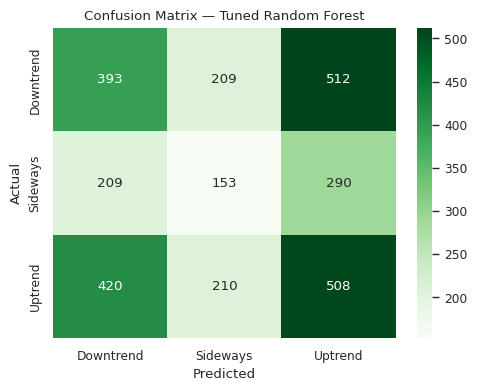

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("  HYPERPARAMETER TUNING — RANDOM FOREST")
print("="*60)

# ---------------------------------------------------------
# 1. Extract the best-performing model (Random Forest)
# ---------------------------------------------------------
best_rf = models["Random_Forest"]

# ---------------------------------------------------------
# 2. Define a simple, beginner-friendly parameter grid
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200, 300],          # number of trees
    "max_depth": [None, 5, 10, 20],           # tree depth
    "min_samples_split": [2, 5, 10],          # split sensitivity
    "min_samples_leaf": [1, 2, 4],            # leaf size
}

# ---------------------------------------------------------
# 3. Set up GridSearchCV
# ---------------------------------------------------------
grid_search = GridSearchCV(
    estimator=best_rf,
    param_grid=param_grid,
    cv=3,                     # 3-fold cross-validation
    scoring="f1_macro",       # balanced metric for 3 classes
    n_jobs=-1,                # use all CPU cores
    verbose=2                 # show progress
)

# ---------------------------------------------------------
# 4. Run the grid search
# ---------------------------------------------------------
print("\nRunning GridSearchCV... this may take a moment.\n")
grid_search.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 5. Show the best results
# ---------------------------------------------------------
print("\n" + "-"*60)
print("  BEST PARAMETERS FOUND")
print("-"*60)
print(grid_search.best_params_)

print("\nBest Macro F1 Score:", grid_search.best_score_)

# ---------------------------------------------------------
# 6. Evaluate tuned model on the test set
# ---------------------------------------------------------
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("\n" + "-"*60)
print("  PERFORMANCE OF TUNED RANDOM FOREST")
print("-"*60)
print(classification_report(y_test, y_pred_tuned, target_names=encoder.classes_))

# ---------------------------------------------------------
# 7. Confusion Matrix for the tuned model
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_tuned, labels=np.arange(len(encoder.classes_)))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix — Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show();